<a href="https://colab.research.google.com/github/sdg331/BDA404/blob/main/titanic_analysis_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 타이타닉 생존률 분석 (Colab용)

승객 1,309명 데이터를 단계별로 분석합니다.

**실행 방법**: 위에서부터 셀을 순서대로 실행(`Shift+Enter`)하세요.
- STEP 0  데이터 업로드 & 전처리
- STEP 1  성별 생존률
- STEP 2  가족 구성원별 생존률
- STEP 3  탑승지 · 요금 · 좌석 등급별 생존률
- STEP 4  나이별 생존률
- STEP 5  추가로 발견한 상관관계


## ⚙️ 0-1. 환경 설정 — 한글 폰트 설치 & 라이브러리

In [1]:
# 한글 폰트(나눔고딕) 설치 — Colab에는 기본 한글 폰트가 없습니다.
!sudo apt-get -qq -y install fonts-nanum > /dev/null

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# seaborn 테마를 먼저 적용한 뒤 폰트를 지정해야 폰트가 덮어써지지 않음
sns.set_style("whitegrid")

# 설치한 나눔고딕을 matplotlib에 등록 (런타임 재시작 없이 바로 적용)
FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(FONT_PATH)
plt.rcParams["font.family"] = fm.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
plt.rcParams["figure.dpi"] = 110

# 공통 색상 팔레트 (생존=초록, 사망=빨강 계열)
C_SURV, C_DIED = "#2a9d8f", "#e76f51"
C_RATE = "#264653"

# 막대 위에 수치 라벨을 표시하는 헬퍼 함수
def annotate_rate(ax, fmt="{:.1f}%", offset=1.5):
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=9,
                        xytext=(0, offset), textcoords="offset points")

print("✅ 준비 완료 — 한글 폰트:", plt.rcParams["font.family"][0])


debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
✅ 준비 완료 — 한글 폰트: NanumGothic


## 📂 0-2. 데이터 업로드

아래 셀을 실행하면 파일 선택 창이 뜹니다. **`titanic.csv`** 를 선택하세요.

> 이미 파일이 업로드돼 있으면 업로드 창을 건너뜁니다.
> Google Drive에 파일이 있다면, 이 셀 대신 드라이브를 마운트해
> `pd.read_csv("/content/drive/MyDrive/경로/titanic.csv", index_col=0)` 로 불러와도 됩니다.


In [2]:
import os

if not os.path.exists("titanic.csv"):
    from google.colab import files
    uploaded = files.upload()          # titanic.csv 를 선택
    # 업로드한 파일명이 다를 경우 자동으로 첫 csv 를 사용
    csv_name = next(k for k in uploaded if k.lower().endswith(".csv"))
    if csv_name != "titanic.csv":
        os.rename(csv_name, "titanic.csv")

df = pd.read_csv("titanic.csv", index_col=0)
print("불러온 데이터 크기:", df.shape)
df.head()


불러온 데이터 크기: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## STEP 0. 데이터 개요 & 전처리

결측치를 합리적인 값으로 채우고, 그래프에 쓸 한글 라벨 컬럼을 만듭니다.
- **나이**: 좌석등급·성별별 중앙값으로 채움 (263건 결측)
- **요금**: 좌석등급별 중앙값으로 채움 (1건 결측)
- **탑승지**: 최빈값으로 채움 (2건 결측)


In [3]:
print(f"전체 승객 수 : {len(df):,}명")
print(f"전체 생존률  : {df['survived'].mean()*100:.1f}%  "
      f"(생존 {df['survived'].sum()}명 / 사망 {(df['survived']==0).sum()}명)")
print(f"결측치 → 나이 {df['age'].isnull().sum()}건, "
      f"요금 {df['fare'].isnull().sum()}건, "
      f"탑승지 {df['embarked'].isnull().sum()}건")

# 결측치 처리
df["age"]  = df.groupby(["pclass", "sex"])["age"].transform(lambda s: s.fillna(s.median()))
df["fare"] = df.groupby("pclass")["fare"].transform(lambda s: s.fillna(s.median()))
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# 그래프용 한글 라벨 컬럼
df["sex_kr"]      = df["sex"].map({"male": "남성", "female": "여성"})
df["class_kr"]    = df["pclass"].map({1: "1등석", 2: "2등석", 3: "3등석"})
df["embarked_kr"] = df["embarked"].map(
    {"S": "사우샘프턴(S)", "C": "셰르부르(C)", "Q": "퀸스타운(Q)"})

print("\n✅ 전처리 완료")


전체 승객 수 : 1,309명
전체 생존률  : 38.2%  (생존 500명 / 사망 809명)
결측치 → 나이 263건, 요금 1건, 탑승지 2건

✅ 전처리 완료


## STEP 1. 성별 생존률

가장 강력한 단일 변수입니다. "여성과 어린이 먼저" 원칙을 확인합니다.

        mean  count
sex_kr             
남성      19.1    843
여성      72.7    466


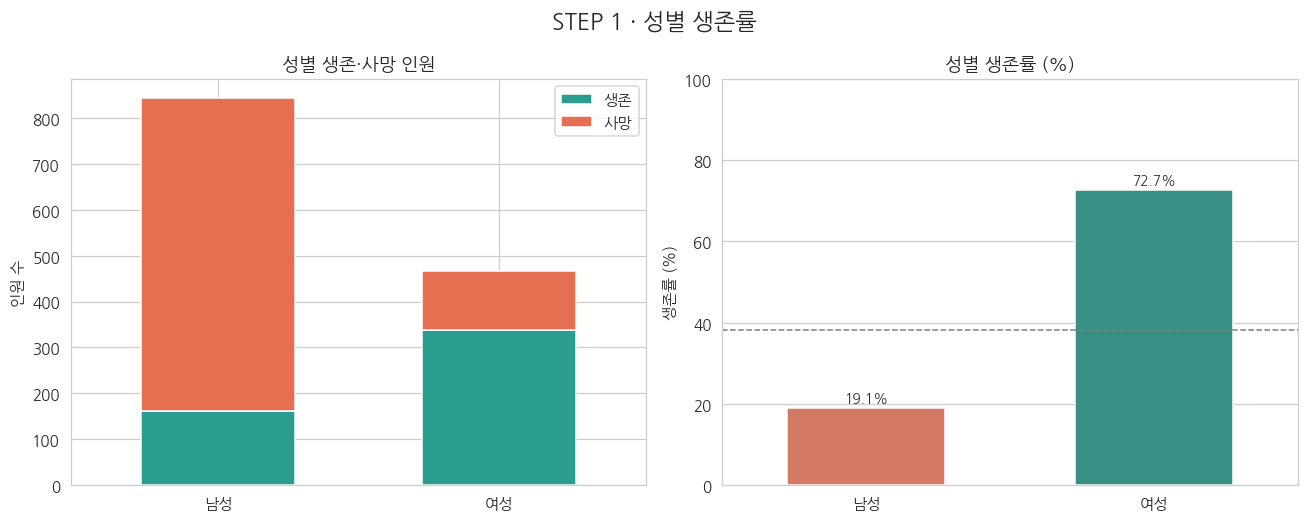

In [4]:
sex_rate = df.groupby("sex_kr")["survived"].agg(["mean", "count"])
sex_rate["mean"] *= 100
print(sex_rate.round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
fig.suptitle("STEP 1 · 성별 생존률", fontsize=15, fontweight="bold")

# (좌) 성별 생존/사망 인원
ct = pd.crosstab(df["sex_kr"], df["survived"])
ct.columns = ["사망", "생존"]
ct[["생존", "사망"]].plot(kind="bar", stacked=True, ax=ax[0],
                          color=[C_SURV, C_DIED], width=0.55)
ax[0].set_title("성별 생존·사망 인원")
ax[0].set_xlabel(""); ax[0].set_ylabel("인원 수")
ax[0].tick_params(axis="x", rotation=0)

# (우) 성별 생존률
sns.barplot(x=sex_rate.index, y=sex_rate["mean"], ax=ax[1],
            palette=[C_DIED, C_SURV], width=0.55)
ax[1].set_title("성별 생존률 (%)")
ax[1].set_xlabel(""); ax[1].set_ylabel("생존률 (%)"); ax[1].set_ylim(0, 100)
ax[1].axhline(df["survived"].mean()*100, ls="--", color="gray", lw=1)
annotate_rate(ax[1])
plt.tight_layout(); plt.show()


## STEP 2. 가족 구성원별 생존률

`sibsp`(형제·배우자) + `parch`(부모·자녀) + 본인 = **가족 규모**.
혼자/대가족은 불리하고, 2~4인 가족이 가장 유리한 **U자형** 관계가 나타납니다.

             mean  count
family_size             
1            30.3    790
2            53.6    235
3            56.6    159
4            69.8     43
5            27.3     22
6            20.0     25
7            25.0     16
8             0.0      8
11            0.0     11


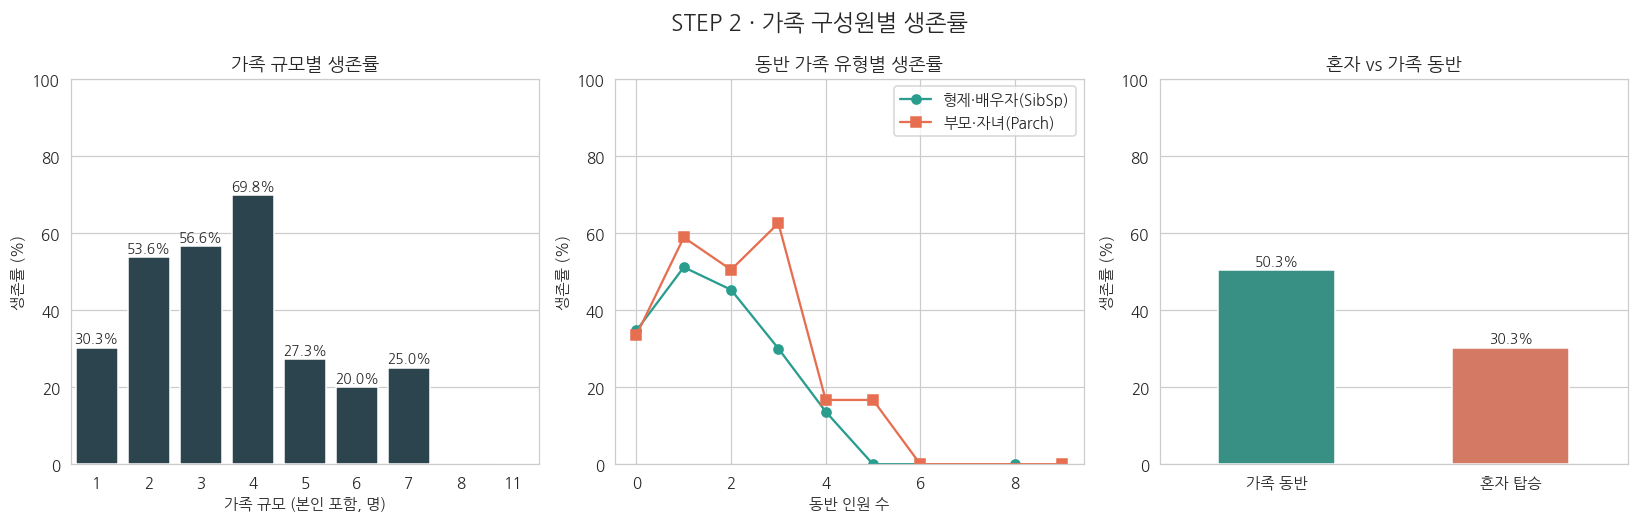

In [5]:
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["alone"] = np.where(df["family_size"] == 1, "혼자 탑승", "가족 동반")

fam = df.groupby("family_size")["survived"].agg(["mean", "count"])
fam["mean"] *= 100
print(fam.round(1))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle("STEP 2 · 가족 구성원별 생존률", fontsize=15, fontweight="bold")

# (1) 가족 규모별 생존률
sns.barplot(x=fam.index, y=fam["mean"], ax=ax[0], color=C_RATE)
ax[0].set_title("가족 규모별 생존률")
ax[0].set_xlabel("가족 규모 (본인 포함, 명)"); ax[0].set_ylabel("생존률 (%)")
ax[0].set_ylim(0, 100); annotate_rate(ax[0])

# (2) 형제·배우자 / 부모·자녀 수별 생존률
sib = df.groupby("sibsp")["survived"].mean() * 100
par = df.groupby("parch")["survived"].mean() * 100
ax[1].plot(sib.index, sib.values, "o-", color=C_SURV, label="형제·배우자(SibSp)")
ax[1].plot(par.index, par.values, "s-", color=C_DIED, label="부모·자녀(Parch)")
ax[1].set_title("동반 가족 유형별 생존률")
ax[1].set_xlabel("동반 인원 수"); ax[1].set_ylabel("생존률 (%)")
ax[1].set_ylim(0, 100); ax[1].legend()

# (3) 혼자 vs 가족 동반
al = df.groupby("alone")["survived"].mean() * 100
sns.barplot(x=al.index, y=al.values, ax=ax[2],
            palette=[C_SURV, C_DIED], width=0.5)
ax[2].set_title("혼자 vs 가족 동반")
ax[2].set_xlabel(""); ax[2].set_ylabel("생존률 (%)"); ax[2].set_ylim(0, 100)
annotate_rate(ax[2])
plt.tight_layout(); plt.show()


## STEP 3. 탑승지 · 요금 · 좌석 등급별 생존률

요금은 4분위 구간으로 나눠 비교합니다. 셰르부르(C)가 높아 보이는 것은
1등석 승객 비율이 높기 때문인 **간접 효과**라는 점에 주의하세요.

[탑승지별]
embarked_kr
사우샘프턴(S)    33.4
셰르부르(C)     55.6
퀸스타운(Q)     35.8
Name: survived, dtype: float64
[등급별]
class_kr
1등석    61.9
2등석    43.0
3등석    25.5
Name: survived, dtype: float64
[요금 구간별]
fare_band
저가\n(하위25%)    22.8
중저가            28.3
중고가            43.6
고가\n(상위25%)    58.5
Name: survived, dtype: float64


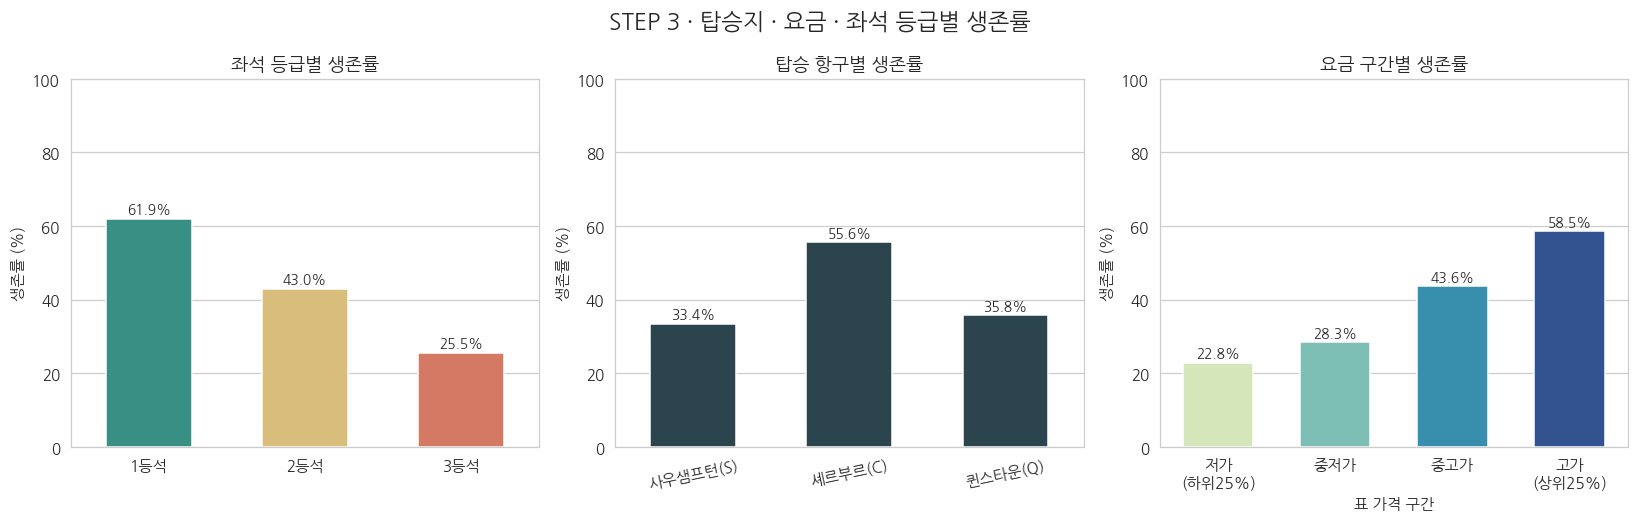

In [6]:
df["fare_band"] = pd.qcut(df["fare"], 4,
    labels=["저가\n(하위25%)", "중저가", "중고가", "고가\n(상위25%)"])

print("[탑승지별]"); print((df.groupby("embarked_kr")["survived"].mean()*100).round(1))
print("[등급별]");   print((df.groupby("class_kr")["survived"].mean()*100).round(1))
print("[요금 구간별]")
print((df.groupby("fare_band", observed=True)["survived"].mean()*100).round(1))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle("STEP 3 · 탑승지 · 요금 · 좌석 등급별 생존률",
             fontsize=15, fontweight="bold")

# (1) 좌석 등급
cls = df.groupby("class_kr")["survived"].mean() * 100
sns.barplot(x=cls.index, y=cls.values, ax=ax[0],
            palette=["#2a9d8f", "#e9c46a", "#e76f51"], width=0.55)
ax[0].set_title("좌석 등급별 생존률")
ax[0].set_xlabel(""); ax[0].set_ylabel("생존률 (%)"); ax[0].set_ylim(0, 100)
annotate_rate(ax[0])

# (2) 탑승지
emb = df.groupby("embarked_kr")["survived"].mean() * 100
sns.barplot(x=emb.index, y=emb.values, ax=ax[1], color=C_RATE, width=0.55)
ax[1].set_title("탑승 항구별 생존률")
ax[1].set_xlabel(""); ax[1].set_ylabel("생존률 (%)"); ax[1].set_ylim(0, 100)
ax[1].tick_params(axis="x", rotation=12); annotate_rate(ax[1])

# (3) 요금 구간
far = df.groupby("fare_band", observed=True)["survived"].mean() * 100
sns.barplot(x=far.index, y=far.values, ax=ax[2], palette="YlGnBu", width=0.6)
ax[2].set_title("요금 구간별 생존률")
ax[2].set_xlabel("표 가격 구간"); ax[2].set_ylabel("생존률 (%)")
ax[2].set_ylim(0, 100); annotate_rate(ax[2])
plt.tight_layout(); plt.show()


## STEP 4. 나이별 생존률

연령대별 생존률과, 생존자/사망자의 나이 분포를 함께 봅니다.
어린이만 두드러지게 높고, 성인 구간은 큰 차이가 없습니다.

              mean  count
age_band                 
어린이\n(0-12)   57.4     94
청소년\n(13-18)  41.4     99
청년\n(19-30)   32.3    640
중년\n(31-45)   42.4    321
장년\n(46-60)   44.3    122
노년\n(60+)     24.2     33


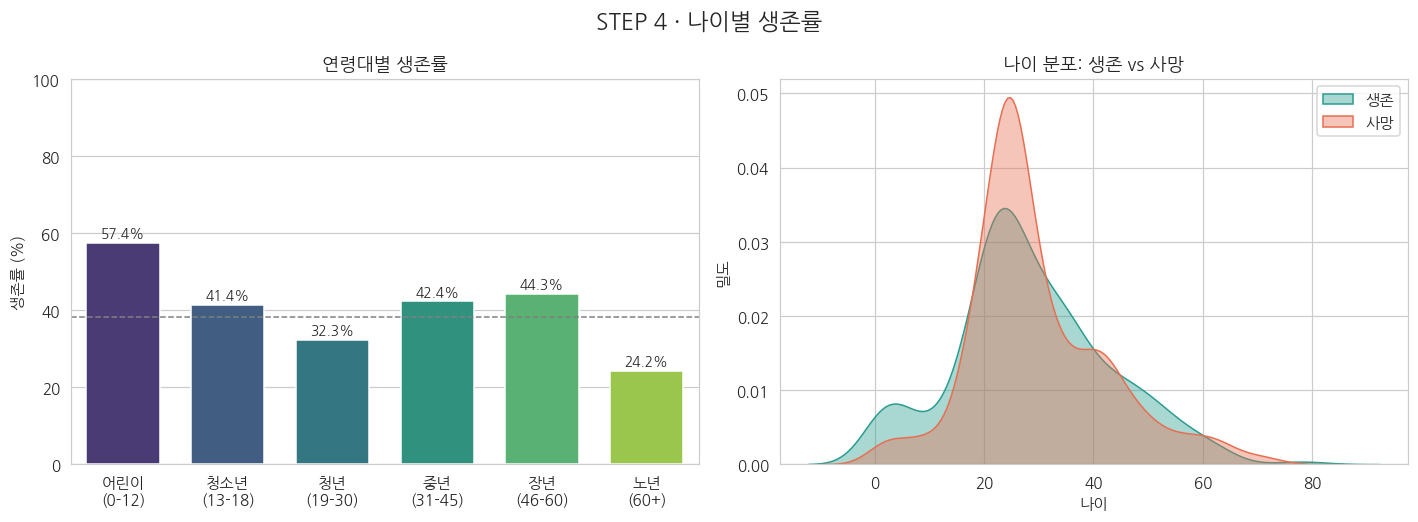

In [7]:
bins   = [0, 12, 18, 30, 45, 60, 100]
labels = ["어린이\n(0-12)", "청소년\n(13-18)", "청년\n(19-30)",
          "중년\n(31-45)", "장년\n(46-60)", "노년\n(60+)"]
df["age_band"] = pd.cut(df["age"], bins=bins, labels=labels)

age_rate = df.groupby("age_band", observed=True)["survived"].agg(["mean", "count"])
age_rate["mean"] *= 100
print(age_rate.round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("STEP 4 · 나이별 생존률", fontsize=15, fontweight="bold")

# (좌) 연령대별 생존률
sns.barplot(x=age_rate.index, y=age_rate["mean"], ax=ax[0],
            palette="viridis", width=0.7)
ax[0].set_title("연령대별 생존률")
ax[0].set_xlabel(""); ax[0].set_ylabel("생존률 (%)"); ax[0].set_ylim(0, 100)
ax[0].axhline(df["survived"].mean()*100, ls="--", color="gray", lw=1)
annotate_rate(ax[0])

# (우) 나이 분포: 생존 vs 사망
for v, c, lab in [(1, C_SURV, "생존"), (0, C_DIED, "사망")]:
    sns.kdeplot(df.loc[df["survived"] == v, "age"], ax=ax[1],
                fill=True, alpha=0.4, color=c, label=lab)
ax[1].set_title("나이 분포: 생존 vs 사망")
ax[1].set_xlabel("나이"); ax[1].set_ylabel("밀도"); ax[1].legend()
plt.tight_layout(); plt.show()


## STEP 5. 추가로 발견한 상관관계

기본 4개 항목 외에 놓치기 쉬운 관계 4가지를 추가로 분석합니다.
1. **호칭(Title)** — 이름에서 추출한 사회적 지위/성별/연령의 압축 정보
2. **성별 × 좌석 등급** 교차 — 두 변수가 곱해질 때의 극단적 격차
3. **객실정보 기록 여부** — 기록 자체가 상위 계층의 대리 지표
4. **상관계수 히트맵** — 변수 간 관계 한눈에 보기


[호칭별 생존률]
title_grp
Mr        16.2
지위/직함     37.9
Master    50.8
Miss      67.8
Mrs       78.8
Name: survived, dtype: float64

[객실정보 기록 여부별 생존률]
cabin_known
객실정보 없음    30.3
객실정보 있음    65.4
Name: survived, dtype: float64


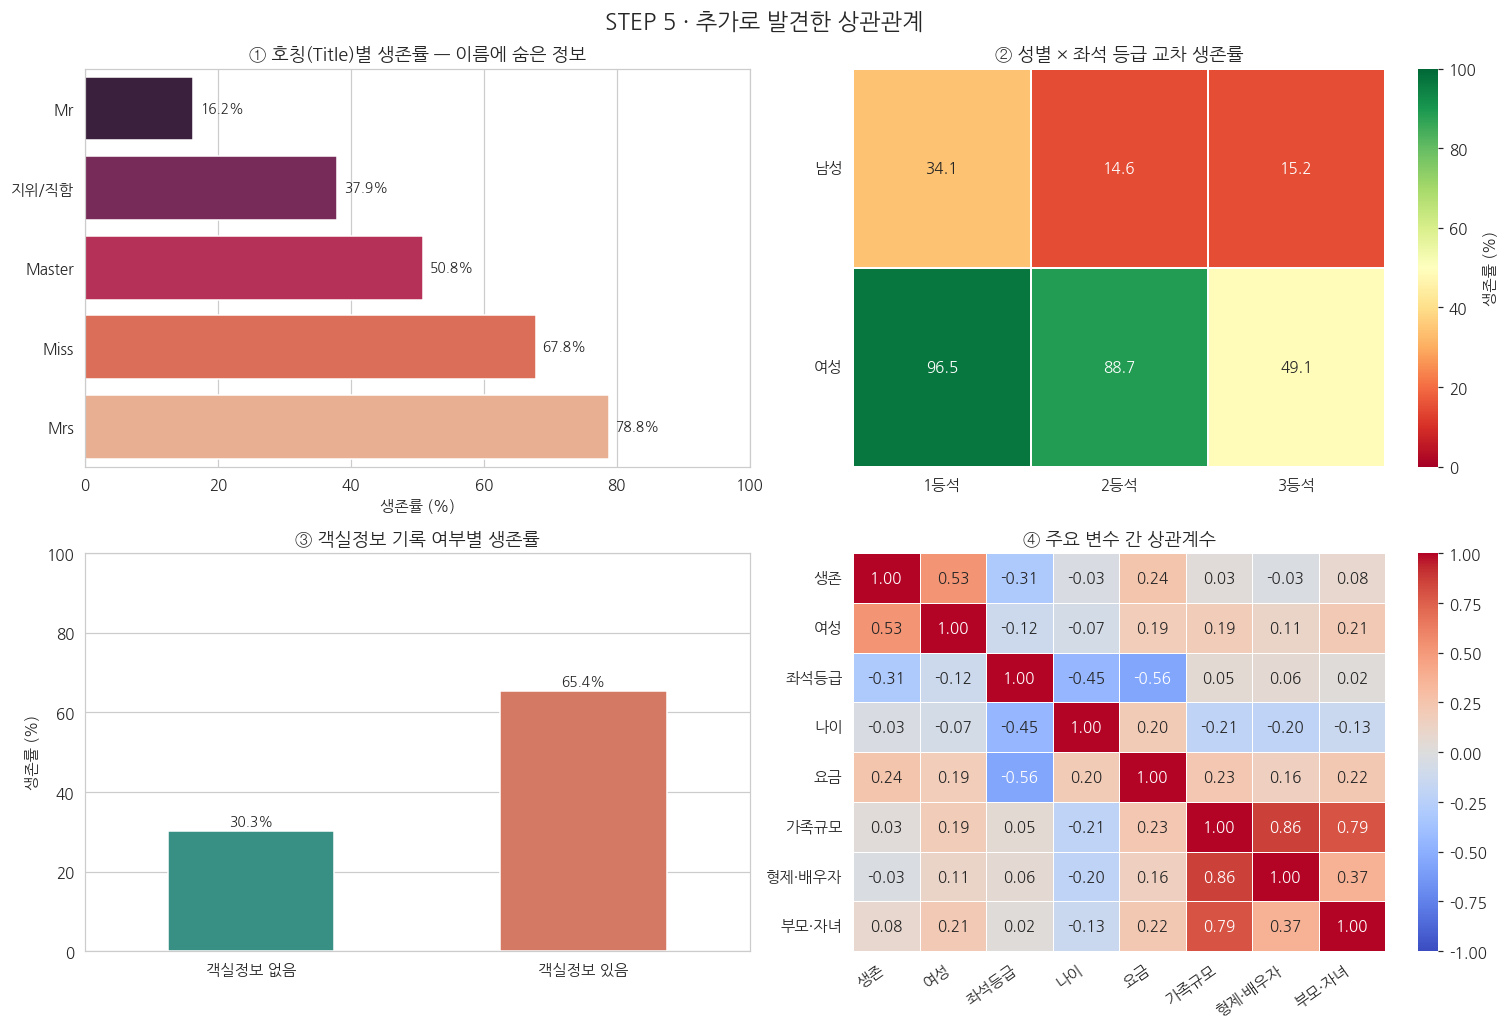


생존과의 상관계수 (절댓값 큰 순):
여성        0.529
좌석등급      0.312
요금        0.244
부모·자녀     0.083
나이        0.034
형제·배우자    0.028
가족규모      0.027
Name: 생존, dtype: float64


In [8]:
# 5-1. 이름에서 호칭(Title) 추출
df["title"] = df["name"].str.extract(r",\s*([^.]+)\.")
title_map = {
    "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
    "Ms": "Miss", "Mlle": "Miss", "Mme": "Mrs",
}
df["title_grp"] = df["title"].map(title_map).fillna("지위/직함")
ttl = (df.groupby("title_grp")["survived"].mean() * 100).sort_values()
print("[호칭별 생존률]"); print(ttl.round(1))

# 5-2. 객실(Cabin) 정보 기록 여부
df["cabin_known"] = np.where(df["cabin"].notnull(), "객실정보 있음", "객실정보 없음")
print("\n[객실정보 기록 여부별 생존률]")
print((df.groupby("cabin_known")["survived"].mean() * 100).round(1))

fig, ax = plt.subplots(2, 2, figsize=(14, 9.5))
fig.suptitle("STEP 5 · 추가로 발견한 상관관계", fontsize=15, fontweight="bold")

# ① 호칭별 생존률
sns.barplot(x=ttl.values, y=ttl.index, ax=ax[0, 0], palette="rocket", orient="h")
ax[0, 0].set_title("① 호칭(Title)별 생존률 — 이름에 숨은 정보")
ax[0, 0].set_xlabel("생존률 (%)"); ax[0, 0].set_ylabel(""); ax[0, 0].set_xlim(0, 100)
for p in ax[0, 0].patches:
    ax[0, 0].annotate(f"{p.get_width():.1f}%",
                      (p.get_width() + 1, p.get_y() + p.get_height()/2),
                      va="center", fontsize=9)

# ② 성별 × 좌석 등급 교차 생존률
pivot = df.pivot_table("survived", "sex_kr", "class_kr", aggfunc="mean") * 100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax[0, 1],
            vmin=0, vmax=100, cbar_kws={"label": "생존률 (%)"},
            linewidths=1, linecolor="white")
ax[0, 1].set_title("② 성별 × 좌석 등급 교차 생존률")
ax[0, 1].set_xlabel(""); ax[0, 1].set_ylabel("")
ax[0, 1].tick_params(axis="y", rotation=0)

# ③ 객실정보 기록 여부
cab = df.groupby("cabin_known")["survived"].mean() * 100
sns.barplot(x=cab.index, y=cab.values, ax=ax[1, 0],
            palette=[C_SURV, C_DIED], width=0.5)
ax[1, 0].set_title("③ 객실정보 기록 여부별 생존률")
ax[1, 0].set_xlabel(""); ax[1, 0].set_ylabel("생존률 (%)"); ax[1, 0].set_ylim(0, 100)
annotate_rate(ax[1, 0])

# ④ 주요 변수 상관관계 히트맵
df["is_female"] = (df["sex"] == "female").astype(int)
corr_cols = {
    "survived": "생존", "is_female": "여성", "pclass": "좌석등급",
    "age": "나이", "fare": "요금", "family_size": "가족규모",
    "sibsp": "형제·배우자", "parch": "부모·자녀",
}
corr = df[list(corr_cols)].corr().rename(index=corr_cols, columns=corr_cols)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax[1, 1], vmin=-1, vmax=1, linewidths=0.5, linecolor="white")
ax[1, 1].set_title("④ 주요 변수 간 상관계수")
ax[1, 1].tick_params(axis="y", rotation=0)
ax[1, 1].tick_params(axis="x", rotation=35)
for lbl in ax[1, 1].get_xticklabels():
    lbl.set_ha("right")
plt.tight_layout(); plt.show()

print("\n생존과의 상관계수 (절댓값 큰 순):")
print(corr["생존"].drop("생존").abs().sort_values(ascending=False).round(3))


## 📌 핵심 요약

| 변수 | 발견 | 생존 상관계수 |
|---|---|---|
| 성별 | 여성 72.7% vs 남성 19.1% | **0.53** (가장 강함) |
| 좌석 등급 | 1등석 61.9% → 3등석 25.5% | 0.31 |
| 요금 | 고가 58.5% vs 저가 22.8% | 0.24 |
| 가족 규모 | 2~4인 유리, 혼자·대가족 불리 (U자형) | — |
| 나이 | 어린이 57.4%만 두드러짐 | 0.03 (약함) |
| 호칭 | Mrs 78.8% vs Mr 16.2% | — |

**주의**: `가족규모`와 `형제·배우자`는 상관 0.86으로 강하게 겹칩니다(다중공선성).
예측 모델을 만들 때는 둘 중 하나만 사용하세요.
